In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [2]:
df = pd.read_csv("ecommerce_customer_data_custom_ratios.csv")
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [4]:
df.shape

(250000, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [6]:
df.isna().sum()

Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47596
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64

In [8]:
# Handle missing values in Returns
df['Returns'] = df['Returns'].fillna(0)

In [9]:
# Convert date
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

In [10]:
# Drop duplicate column (keep one Age column)
df = df.drop(columns=['Customer Age'])

In [11]:
# Rename columns for ease
df.columns = df.columns.str.replace(" ", "_")

In [12]:
df.describe()

,Customer_ID,Purchase_Date,Product_Price,Quantity,Total_Purchase_Amount,Returns,Age,Churn
count,250000.00000,250000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,25004.03624,2021-11-06 23:31:24.372304384,254.659512,2.998896,2725.370732,0.403076,43.940528,0.199496
min,1.00000,2020-01-01 00:15:00,10.000000,1.000000,100.000000,0.000000,18.000000,0.000000
25%,12497.75000,2020-12-02 19:33:23.249999872,132.000000,2.000000,1477.000000,0.000000,31.000000,0.000000
50%,25018.00000,2021-11-06 13:10:59,255.000000,3.000000,2724.000000,0.000000,44.000000,0.000000
75%,37506.00000,2022-10-11 03:42:32.750000128,377.000000,4.000000,3974.000000,1.000000,57.000000,0.000000
max,50000.00000,2023-09-15 12:24:08,500.000000,5.000000,5350.000000,1.000000,70.000000,1.000000
std,14428.27959,NaN,141.568577,1.414694,1442.933565,0.490517,15.350246,0.399622


In [13]:
# Feature Engineering
snapshot_date = df['Purchase_Date'].max() + pd.Timedelta(days=1)

In [14]:
# creating the rfm table
rfm = df.groupby('Customer_ID').agg({
    'Purchase_Date': lambda x: (snapshot_date - x.max()).days,
    'Customer_ID': 'count',
    'Total_Purchase_Amount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [15]:
# customer segmentation
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'], 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

In [16]:
rfm['Segment'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

### visualizations

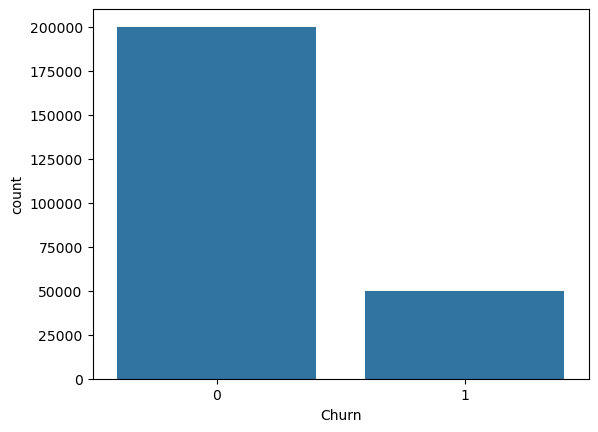

In [31]:
# Churn Distribution
sns.countplot(x='Churn', data=df)
plt.show()

Top 10 Product Categories:
Product_Category
Clothing       75052
Books          74912
Electronics    50185
Home           49851
Name: count, dtype: int64


C:\Users\INDIA\AppData\Local\Temp\ipykernel_2040\3309547076.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')


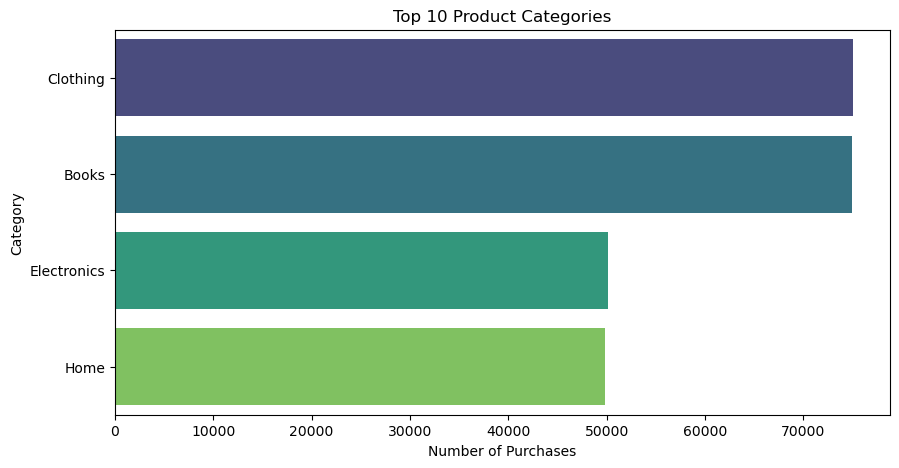

In [32]:
# 2. Most popular product categories
top_categories = df['Product_Category'].value_counts().head(10)
print("Top 10 Product Categories:")
print(top_categories)

plt.figure(figsize=(10,5))
sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')
plt.title("Top 10 Product Categories")
plt.xlabel("Number of Purchases")
plt.ylabel("Category")
plt.show()


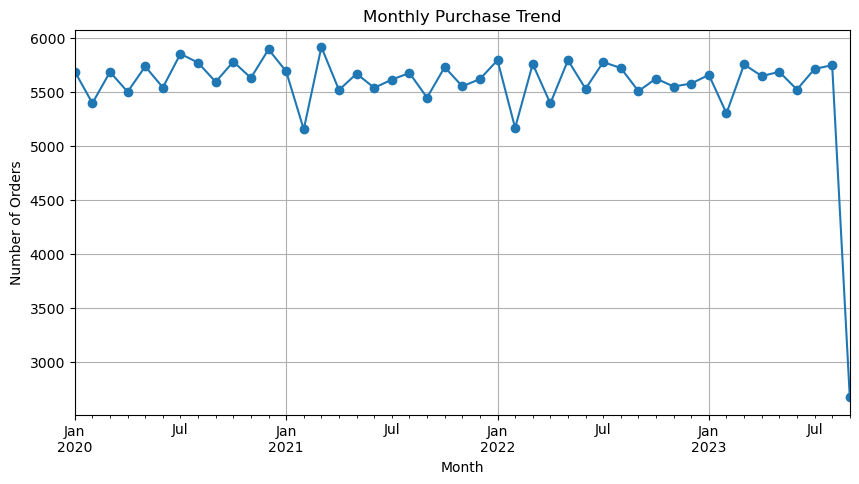

In [27]:
# 3. Customer purchase trends over time
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'])

monthly_trends = df.groupby(df['Purchase_Date'].dt.to_period('M')).size()
monthly_trends.index = monthly_trends.index.to_timestamp()

plt.figure(figsize=(10,5))
monthly_trends.plot(marker='o')
plt.title("Monthly Purchase Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.grid(True)
plt.show()

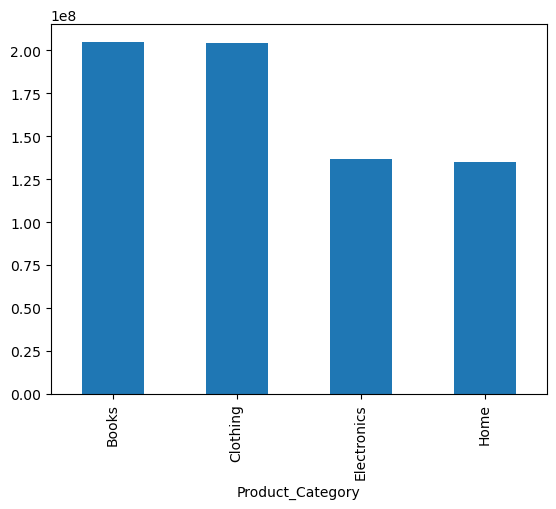

In [28]:
#4 Revenue by category

df.groupby('Product_Category')['Total_Purchase_Amount'].sum().plot(kind='bar')
plt.show()

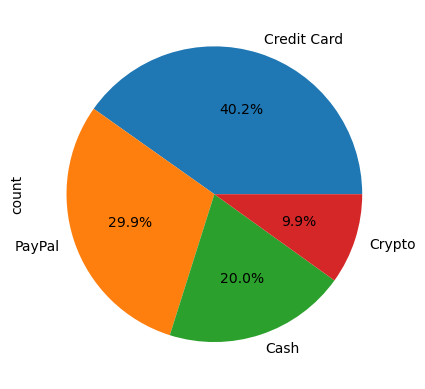

In [30]:
#5  Payment Method
df['Payment_Method'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.show()

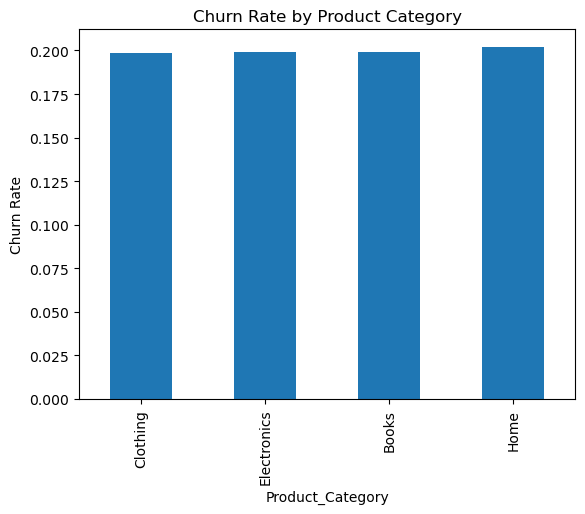

In [33]:
#6 Churn Rate by Product Category
churn_category = df.groupby('Product_Category')['Churn'].mean().sort_values()

churn_category.plot(kind='bar')
plt.title("Churn Rate by Product Category")
plt.ylabel("Churn Rate")
plt.show()

Correlation Matrix:
                       Product_Price  Quantity  Total_Purchase_Amount  \
Product_Price               1.000000 -0.000308              -0.002336   
Quantity                   -0.000308  1.000000              -0.000096   
Total_Purchase_Amount      -0.002336 -0.000096               1.000000   
Returns                    -0.003218  0.001529               0.000189   
Age                        -0.003860  0.000041               0.051847   

                        Returns       Age  
Product_Price         -0.003218 -0.003860  
Quantity               0.001529  0.000041  
Total_Purchase_Amount  0.000189  0.051847  
Returns                1.000000 -0.001069  
Age                   -0.001069  1.000000  


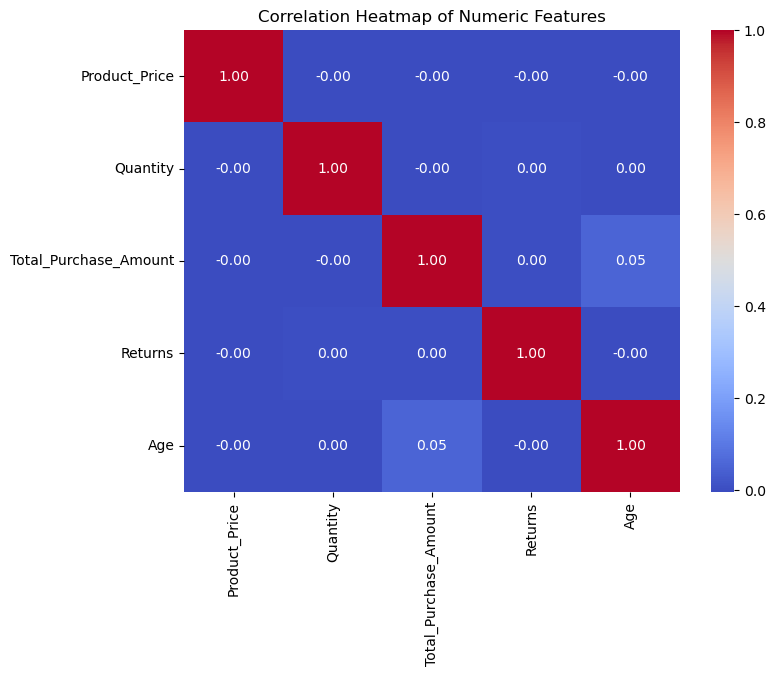

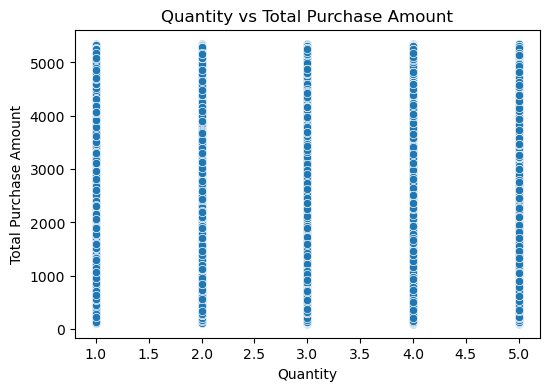

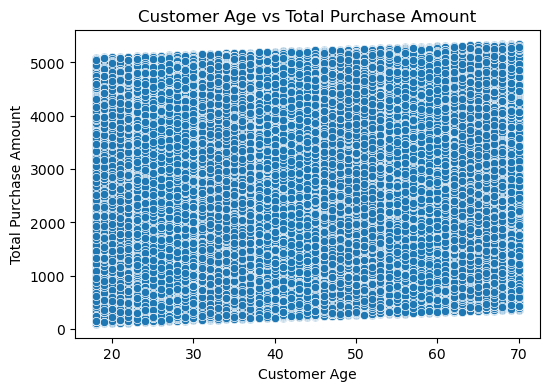

In [39]:
# Step 7: Correlation & Feature Analysis

# Select numeric columns for correlation
numeric_cols = ['Product_Price', 'Quantity', 'Total_Purchase_Amount', 'Returns', 'Age']

# 1. Correlation matrix
corr_matrix = df[numeric_cols].corr()
print("Correlation Matrix:")
print(corr_matrix)

# 2. Visualize correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

# 3. Scatter plots for interesting relationships
plt.figure(figsize=(6,4))
sns.scatterplot(x='Quantity', y='Total_Purchase_Amount', data=df)
plt.title("Quantity vs Total Purchase Amount")
plt.xlabel("Quantity")
plt.ylabel("Total Purchase Amount")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x='Age', y='Total_Purchase_Amount', data=df)
plt.title("Customer Age vs Total Purchase Amount")
plt.xlabel("Customer Age")
plt.ylabel("Total Purchase Amount")
plt.show()

### Summary & Recommendations
#### Key Insights:
- Clothing and Books are the most purchased categories (75K each), higher than Electronics and Home.
- Monthly purchases are stable (5400–5800 orders) with no strong growth trend; last drop is likely incomplete data.
- Quantity and total purchase amount are positively related, but price variation impacts revenue.
- Customer age shows no strong impact on spending behavior.
- Around 20% customers have churned, indicating scope for improvement.

#### Recommendations:
- Focus on top categories (Clothing, Books) to maximize revenue.
- Run campaigns to boost growth beyond stable trends.
- Promote high-value products to increase revenue.
- Use behavior-based targeting instead of age-based segmentation.
- Reduce churn through better engagement and customer experience.

## FINAL BUSINESS SUMMARY

 “The analysis reveals that the business has a stable customer base with moderate churn. A few product categories such as Clothing and Books dominate both purchases and revenue. Payment behavior shows strong preference toward digital methods, especially credit cards. Customer behavior is diverse with no strong dependency on age or individual factors, indicating the need for personalized and data-driven strategies.”